## Importing Libraries & Setting Up

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import copy
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
manualSeed = 999
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
print("Random Seed:", manualSeed)

# PATHS CONFIGURATION
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
meta_dir = "/kaggle/input/isic-2024-challenge/"
save_dir = '/kaggle/working/processed_images'
os.makedirs(save_dir, exist_ok=True)

image_files = os.listdir(image_dir)[:10]

for i, file_name in enumerate(image_files, 1):
    # iterate over the image files that get and
    # join the path to open each image
    image_path = os.path.join(image_dir, file_name)
    with Image.open(image_path) as img:
        print(f"Image {i}: {file_name} - Size: {img.size}") 


Random Seed: 999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Load CSV data & balance the classes (malignant vs benign)

In [13]:
df = pd.read_csv(meta_dir + "train-metadata.csv")
print(f"Total dataset size: {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts()}")

# Keep all malignant and 10,000 benign samples
malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

df_trainval, df_test = train_test_split(
    df_filtered,
    test_size=0.10,
    random_state=42,
    stratify=df_filtered['target']
)
df_trainval = df_trainval.reset_index(drop=True)
df_test     = df_test.reset_index(drop=True)

print(f"Train+Val : {len(df_trainval)}")
print(f"Test      : {len(df_test)}")
print(f"\nTrain+Val distribution:\n{df_trainval['target'].value_counts()}")
print(f"\nTest distribution:\n{df_test['target'].value_counts()}")

Total dataset size: 401059
Target distribution:
target
0    400666
1       393
Name: count, dtype: int64
Train+Val : 9353
Test      : 1040

Train+Val distribution:
target
0    8999
1     354
Name: count, dtype: int64

Test distribution:
target
0    1001
1      39
Name: count, dtype: int64


In [14]:
!pip install scikit-image

Define two hair removal functions (DullRazor algorithm)

In [15]:
# IMAGE PREPROCESSING FUNCTIONS

def remove_hairs_dullrazor(img):
    """Advanced hair removal using morphological black-hat and inpainting"""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted

def remove_hairs_v2(img):
    """Improved hair removal using morphology and contour masking"""
    img = img.copy()
    kernel = np.ones((15, 15), np.uint8)
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=2)
    blurred = cv2.blur(closed, (15, 15))
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    
    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest_contour], -1, 255, -1)
    mean_color = cv2.mean(img, mask=mask)[:3]
    mean_color = tuple(map(int, mean_color))
    
    result = img.copy()
    h, w = img.shape[:2]
    for y in range(h):
        for x in range(w):
            if mask[y, x]:
                b, g, r = result[y, x]
                if r < mean_color[2]*0.8 or g < mean_color[1]*0.8 or b < mean_color[0]*0.8:
                    result[y, x] = mean_color
    return result

In [16]:
def apply_clahe_lab(img):
    """Apply CLAHE to L channel in LAB color space"""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)
    return img_clahe

def augment_image(img):
    """Return rotated and flipped versions"""
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

In [22]:
print("\n🔄 Processing images...")
new_records = []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")
    
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    # Apply preprocessing
    img = remove_hairs_dullrazor(img)
    img = apply_clahe_lab(img)
    img = remove_hairs_v2(img)
    
    # Save processed original
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})
    
    # Augment malignant cases
    if label == 1:
        aug_imgs = augment_image(img)
        for i, aug_img in enumerate(aug_imgs):
            aug_id = f"{isic_id}_aug{i}"
            aug_path = os.path.join(save_dir, f"{aug_id}.jpg")
            cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            new_records.append({'isic_id': aug_id, 'target': 1})

df_filtered_preprocessed = pd.DataFrame(new_records).reset_index(drop=True)


🔄 Processing images...


100%|██████████| 10393/10393 [12:37<00:00, 13.72it/s]


In [31]:


df_trainval, df_test = train_test_split(
    df_filtered_preprocessed,
    test_size=0.10,
    random_state=42,
    stratify=df_filtered_preprocessed['target']
)

# Step 2: split remaining 90% into 80% train and 10% val
# 0.111 of 90% ≈ 10% of total
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.111,
    stratify=df_trainval['target'],
    random_state=42
)

df_train    = df_train.reset_index(drop=True)
df_val      = df_val.reset_index(drop=True)
df_test     = df_test.reset_index(drop=True)
df_trainval = df_trainval.reset_index(drop=True)

print(f"Train     : {len(df_train)}  | Malignant: {df_train['target'].sum()}")
print(f"Val       : {len(df_val)}    | Malignant: {df_val['target'].sum()}")
print(f"Test      : {len(df_test)}   | Malignant: {df_test['target'].sum()}")
print(f"Total     : {len(df_train) + len(df_val) + len(df_test)}")

Train     : 10201  | Malignant: 2201
Val       : 1274    | Malignant: 275
Test      : 1276   | Malignant: 275
Total     : 12751


In [32]:
# DATASET CLASS

class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [33]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
class EfficientNetBinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        # load EfficientNet‑B0 backbone
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = efficientnet_b0(weights=weights)

        # replace the default classifier → single logit
        in_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_feats, 1)
        )

    def forward(self, x):
        return self.backbone(x)

In [34]:
# TRAINING FUNCTIONS

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_list, labels_list = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(imgs)

        # Handle InceptionV3's aux output
        if isinstance(outputs, tuple):
            logits, aux_logits = outputs
            loss1 = criterion(logits, labels)
            loss2 = criterion(aux_logits, labels)
            loss = loss1 + 0.4 * loss2  # standard weighting for Inception auxiliary loss
        else:
            logits = outputs
            loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits).detach().cpu().numpy() > 0.5).astype(int)
        preds_list.extend(preds.flatten())
        labels_list.extend(labels.cpu().numpy().flatten())

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_list, labels_list = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(imgs)

            # Handle tuple (main, aux) just in case
            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

            loss = criterion(logits, labels)
            running_loss += loss.item() * imgs.size(0)

            preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(int)
            preds_list.extend(preds.flatten())
            labels_list.extend(labels.cpu().numpy().flatten())

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels_list, preds_list)
    return avg_loss, acc


In [35]:
EPOCHS_PER_FOLD = 10
BATCH_SIZE = 32
LEARNING_RATE = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🔧 Using device: {device}")

# Data transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


🔧 Using device: cuda


In [36]:
# TRAINING

# Create datasets
train_dataset = SkinLesionDataset(df_train, save_dir, transform=train_transform)
val_dataset   = SkinLesionDataset(df_val,   save_dir, transform=val_transform)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# Initialize model
model = EfficientNetBinaryClassifier(pretrained=True).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

best_val_acc     = 0.0
best_model_state = None
val_acc_history  = []
train_acc_history = []

# Training loop — 20 epochs
for epoch in range(EPOCHS_PER_FOLD):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)

    scheduler.step()
    val_acc_history.append(val_acc)
    train_acc_history.append(train_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Train: 10201 | Val: 1274
Epoch 1: Train Loss = 0.3264, Train Acc = 0.8646, Val Loss = 0.2577, Val Acc = 0.8932
Epoch 2: Train Loss = 0.2349, Train Acc = 0.8997, Val Loss = 0.1916, Val Acc = 0.9294
Epoch 3: Train Loss = 0.1892, Train Acc = 0.9204, Val Loss = 0.1666, Val Acc = 0.9372
Epoch 4: Train Loss = 0.1443, Train Acc = 0.9437, Val Loss = 0.1330, Val Acc = 0.9435
Epoch 5: Train Loss = 0.1100, Train Acc = 0.9572, Val Loss = 0.1361, Val Acc = 0.9466
Epoch 6: Train Loss = 0.0935, Train Acc = 0.9635, Val Loss = 0.1266, Val Acc = 0.9490
Epoch 7: Train Loss = 0.0740, Train Acc = 0.9714, Val Loss = 0.0950, Val Acc = 0.9647
Epoch 8: Train Loss = 0.0594, Train Acc = 0.9786, Val Loss = 0.0884, Val Acc = 0.9678
Epoch 9: Train Loss = 0.0573, Train Acc = 0.9779, Val Loss = 0.0838, Val Acc = 0.9694
Epoch 10: Train Loss = 0.0370, Train Acc = 0.9881, Val Loss = 0.0741, Val Acc = 0.9733

Best Val Accuracy: 0.9733


In [37]:
# TEST EVALUATION
model.load_state_dict(best_model_state)
model.eval()

test_dataset = SkinLesionDataset(df_test, save_dir, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.9812
Test Loss     : 0.0479


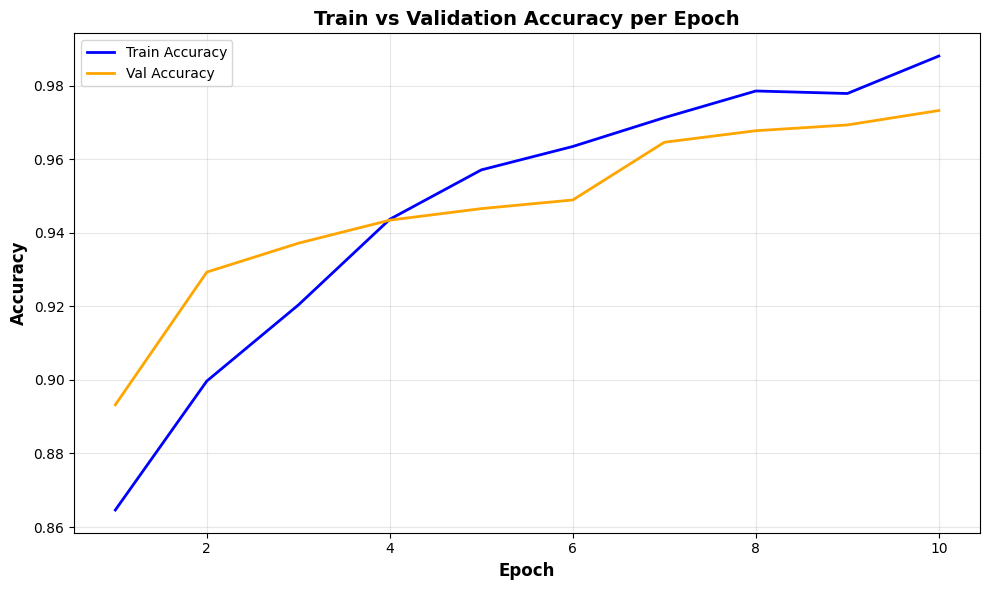

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(train_acc_history) + 1),
         train_acc_history,
         color='blue', linewidth=2, label='Train Accuracy')

plt.plot(range(1, len(val_acc_history) + 1),
         val_acc_history,
         color='orange', linewidth=2, label='Val Accuracy')

plt.title("Train vs Validation Accuracy per Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()